# Importing Lybraries

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import re
import holidays
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
from google.colab import files
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import matplotlib.dates as mdates
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score













# Block 1: Feature Review & Enhancement (%25)

We are predicting the parking occupancy 60 minutes into the future for each parking unit, which allows us to estimate how many spaces will be available one hour from now. The target variable is the occupancy shifted 4 steps ahead in our 15-minute time-series.

In [2]:
parking_df= pd.read_csv('merged_df_cleaned.csv')

In [3]:
parking_df.head()

,Fee,Date,Starting date,End date,Payment type,Amount,Plate,Type,Hope Gps Latitude,Hope Gps Longitude,Unit,Time,PT1 amount,Amount with bonification,Zone,duration
0,REGULAR RATE,8/31/2025 7:55:58 PM,2025-08-31 19:55:58,2025-08-31 20:00:00,BANK CARD,3.5,CKD0022,PARKING,51.179,-115.574,BANFF01- HEALTH UNIT LOT,5,3.5,NaN,DOWNTOWN,4.033333
1,REGULAR RATE,8/31/2025 7:54:20 PM,2025-08-31 19:54:20,2025-08-31 20:00:00,BANK CARD,3.5,CWP3165,PARKING,51.175,-115.572,BANFF18- TOWN HALL LOT,6,3.5,NaN,DOWNTOWN,5.666667
2,REGULAR RATE,8/31/2025 7:53:54 PM,2025-08-31 19:53:54,2025-08-31 20:00:00,PAY BY PHONE,3.5,1626SSB,PARKING,NaN,NaN,NaN,7,3.5,3.5,DOWNTOWN,6.100000
3,REGULAR RATE,8/31/2025 7:51:43 PM,2025-08-31 19:51:43,2025-08-31 20:00:00,PAY BY PHONE,3.5,BYW4665,PARKING,NaN,NaN,NaN,9,3.5,3.5,DOWNTOWN,8.283333
4,REGULAR RATE,8/31/2025 7:51:56 PM,2025-08-31 19:51:56,2025-08-31 20:00:00,PAY BY PHONE,3.5,CVG2233,PARKING,51.178,-115.572,NaN,9,3.5,3.5,DOWNTOWN,8.066667


Plate, Hope Gps Longitude, Hope Gps Latitude, 'Zone', 'PT1 amount', 'Time' fields were dropped because they do not contribute useful information to the forecasting  and introduce noise or unnecessary dimensionality

In [4]:
#removing Plate, Hope Gps Longitude, Hope Gps Latitude 'Zone', 'PT1 amount', 'Time'
parking_df = parking_df.drop(columns=['Plate', 'Hope Gps Longitude', 'Hope Gps Latitude', 'Zone', 'PT1 amount', 'Time'])


These units BANFF99- TEST", "BANFF99V- VIRTUAL" were excluded because they represent test environments rather than real operational parkades, and therefore do not contribute meaningful data to the occupancy model.

In [5]:
parking_df = parking_df[~parking_df["Unit"].isin(["BANFF99- TEST", "BANFF99V- VIRTUAL"])]


In [6]:
df = parking_df.copy()


Because each parking unit contains multiple transactions with different start and end times, we created a feature representing the maximum observed occupancy (max_occupancy). Since the actual parking capacity is not available (client provided us parking capacity file but parking utits didn't match with our dataset parking units), we use this value as a proxy for the true capacity (max_capacity)



In [7]:
# ---  Ensure correct datatypes ---
df['Starting date'] = pd.to_datetime(df['Starting date'])
df['End date'] = pd.to_datetime(df['End date'])

# Remove rows where unit is NaN
df = df[df['Unit'].notna()].copy()

# Prepare results list
results = []

# ---  Loop through each unique unit ---
for unit in df['Unit'].unique():

    df_unit = df[df['Unit'] == unit].copy()

    # Skip rows where end < start just in case
    df_unit = df_unit[df_unit['End date'] >= df_unit['Starting date']]

    # --- 3. Create sweep-line event list ---
    starts = df_unit[['Starting date']].rename(columns={'Starting date': 'time'})
    starts['delta'] = 1

    ends = df_unit[['End date']].rename(columns={'End date': 'time'})
    ends['delta'] = -1

    events = pd.concat([starts, ends], ignore_index=True)

    # Sort by time, break ties by processing +1 before -1
    events = events.sort_values(['time', 'delta'], ascending=[True, False]).reset_index(drop=True)

    # --- Compute occupancy over time ---
    events['occupancy'] = events['delta'].cumsum()

    # ---  Get max occupancy and timestamp ---
    max_occ = events['occupancy'].max()
    max_time = events.loc[events['occupancy'].idxmax(), 'time']

    # Store result
    results.append({
        "Unit": unit,
        "max_occupancy": max_occ,
        "time_of_max": max_time
    })

# ---  Convert results to a dataframe ---
occupancy_summary = pd.DataFrame(results)

print(occupancy_summary)



                               Unit  max_occupancy         time_of_max
0          BANFF01- HEALTH UNIT LOT             52 2024-10-12 13:47:18
1            BANFF18- TOWN HALL LOT             33 2024-08-04 17:56:33
2      BANFF25- TOWN HALL LOT NORTH             24 2024-11-16 15:48:29
3          BANFF28- BEAR PARKADE L2             71 2025-05-17 15:27:05
4    BANFF14- MT ROYAL LOT 1 "EAST"             36 2025-01-18 15:12:07
5         BANFF04- MARTEN 300 BLOCK             16 2025-07-12 13:55:56
6           BANFF12- CARIBOU MASONS             20 2024-09-01 18:16:58
7         BANFF17- CENTRAL PARK LOT             63 2024-02-19 13:15:16
8           BANFF21- LYNX 200 BLOCK             20 2024-01-04 14:28:34
9    BANFF13- MT ROYAL LOT 1 "WEST"             27 2024-11-16 14:43:51
10     BANFF19- BEAR STREET PARKADE             42 2024-05-25 14:28:37
11      BANFF26- FIRE HALL LOT WEST             69 2024-08-04 14:45:39
12  BANFF08- FIRE HALL LOT 1 "WEST"             81 2024-09-01 19:35:46
13  BA

In [8]:
# Keep only the columns we need for merging
occ_per_unit = occupancy_summary[['Unit', 'max_occupancy']].copy()

# Merge max_occupancy back into the main df based on Unit
df = df.merge(occ_per_unit, on='Unit', how='left')


In [9]:
#rename max_occupancy as max_capacity
df = df.rename(columns={'max_occupancy': 'max_capacity'})


In [10]:
df.head()

,Fee,Date,Starting date,End date,Payment type,Amount,Type,Unit,Amount with bonification,duration,max_capacity
0,REGULAR RATE,8/31/2025 7:55:58 PM,2025-08-31 19:55:58,2025-08-31 20:00:00,BANK CARD,3.5,PARKING,BANFF01- HEALTH UNIT LOT,NaN,4.033333,52
1,REGULAR RATE,8/31/2025 7:54:20 PM,2025-08-31 19:54:20,2025-08-31 20:00:00,BANK CARD,3.5,PARKING,BANFF18- TOWN HALL LOT,NaN,5.666667,33
2,REGULAR RATE,8/31/2025 7:51:14 PM,2025-08-31 19:51:14,2025-08-31 20:00:00,BANK CARD,3.5,PARKING,BANFF18- TOWN HALL LOT,NaN,8.766667,33
3,REGULAR RATE,8/31/2025 7:50:12 PM,2025-08-31 19:50:12,2025-08-31 20:00:00,BANK CARD,3.5,PARKING,BANFF25- TOWN HALL LOT NORTH,NaN,9.800000,24
4,REGULAR RATE,8/31/2025 7:48:43 PM,2025-08-31 19:48:43,2025-08-31 20:00:00,BANK CARD,3.5,PARKING,BANFF28- BEAR PARKADE L2,NaN,11.283333,71


After computing the maximum capacity per unit, the dataset was further cleaned and reduced to include only the variables needed for modeling.

In [11]:
# Convert start/end date columns to datetime
df['start'] = pd.to_datetime(df['Starting date'])
df['end']   = pd.to_datetime(df['End date'])

# Remove rows with missing or invalid timestamps
df = df.dropna(subset=['start', 'end'])
df = df[df['end'] > df['start']]

# Keep only needed columns for modeling
df = df[['Unit', 'start', 'end', 'max_capacity']].copy()
# Rename for consistency with the rest of the pipeline
df.rename(columns={'Unit': 'unit'}, inplace=True)

We created a 15-minute occupancy timeline for each unit so the model can clearly understand how busy each unit is throughout the day.
By turning every start and end time into a continuous sequence of occupancy values, we generated a smooth 15-minute time series.
These occupancy values help the model learn short-term trends, sudden changes in demand, and congestion patterns, which improves its ability to predict future occupancy.

In [12]:

# BUILD 15-MINUTE OCCUPANCY (EVENT-BASED)


# Snap to 15-minute grid
df['start_slot'] = df['start'].dt.floor('15min')
df['end_slot']   = df['end'].dt.ceil('15min')   # present up to just before end_slot

# Build event table: +1 at start, -1 at end
starts = df[['unit', 'start_slot', 'max_capacity']].copy()
starts['ts'] = starts['start_slot']
starts['delta'] = 1

ends = df[['unit', 'end_slot', 'max_capacity']].copy()
ends['ts'] = ends['end_slot']
ends['delta'] = -1

events = pd.concat(
    [
        starts[['unit', 'ts', 'delta', 'max_capacity']],
        ends[['unit', 'ts', 'delta', 'max_capacity']]
    ],
    ignore_index=True
)

# Aggregate per unit & timestamp
events = events.groupby(['unit', 'ts'], as_index=False).agg(
    delta=('delta', 'sum'),   # net change in cars at this time
    max_capacity=('max_capacity', 'max') # keep capacity info
)

# For each unit, create full 15-min index and cumulative occupancy
all_series = []

for unit_name, grp in events.groupby('unit'):
    grp = grp.sort_values('ts')

    full_index = pd.date_range(
        start=grp['ts'].min(),
        end=grp['ts'].max(),
        freq='15min'
    )

    grp = grp.set_index('ts').reindex(full_index)

    grp.index.name = 'ts'

    # Fill missing deltas with 0 (no new arrivals/departures)
    grp['delta'] = grp['delta'].fillna(0)

    # Capacity: forward-fill then back-fill
    grp['max_capacity'] = grp['max_capacity'].ffill().bfill()

     # Cumulative sum of deltas gives occupancy over time
    grp['occupancy'] = grp['delta'].cumsum()
    # Add unit identifier back
    grp['unit'] = unit_name

    all_series.append(grp.reset_index())

# Final occupancy dataframe for all units
occupancy_df = pd.concat(all_series, ignore_index=True)
occupancy_df.rename(columns={'index': 'ts'}, inplace=True)  # in case


We also created time-based features such as hour, day of week, weekend indicator, and month to capture seasonal patterns.

Lag features were generated to represent past occupancy levels 15, 30, 45, and 60 minutes prior, helping the model learn short-term temporal dependencies.

Rolling averages over the previous 1 hour and 2 hours were added to smooth out noise and capture recent occupancy trends.

A supervised learning target was defined as the occupancy 60 minutes into the future, framing the task as a forecasting problem.

Finally, rows with missing values were removed, producing a clean modeling dataset containing all engineered features and the future occupancy target.

In [13]:
occ = occupancy_df.copy()

# Sort correctly
occ = occ.sort_values(['unit', 'ts'])

# 1 Time-based features
occ['hour']       = occ['ts'].dt.hour
occ['dayofweek']  = occ['ts'].dt.dayofweek  # 0 = Monday
occ['is_weekend'] = occ['dayofweek'].isin([5, 6]).astype(int)
occ['month']      = occ['ts'].dt.month

# 2 Lag features (k * 15 minutes)
group = occ.groupby('unit', group_keys=False)

for lag in [1, 2, 3, 4]:   # 15, 30, 45, 60 minutes ago
    occ[f'lag_{lag}'] = group['occupancy'].shift(lag)

# Rolling means (past 1h and 2h, excluding current point)
occ['roll_mean_4'] = group['occupancy'].shift(1).rolling(4).mean()
occ['roll_mean_8'] = group['occupancy'].shift(1).rolling(8).mean()

# 3 Target: occupancy 60 minutes ahead (4 * 15 minutes)
occ['target_60'] = group['occupancy'].shift(-4)

# Drop rows where any feature or target is NaN
feature_cols = [
    'occupancy', 'max_capacity',
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
    'roll_mean_4', 'roll_mean_8',
    'hour', 'dayofweek', 'is_weekend', 'month',
    'unit'
]

occ_model = occ.dropna(subset=feature_cols + ['target_60']).copy()

print("Number of training rows:", len(occ_model))
# Save feature table for Streamlit
#occ_model.to_csv("occ_model_features.csv", index=False)
#print("Saved occ_model_features.csv for the app.")


Number of training rows: 1614163


This section encodes the unit identifiers, builds the final feature matrix (X) and target (y), preserves the correct chronological order for time-series forecasting, and performs an 80/20 temporal train–test split so the model is trained on past data and evaluated on future data.


We encoded the unit variable using a label encoder to convert unit names from strings to integers, allowing the model to learn unit-specific patterns.

The final feature matrix X combines current occupancy, capacity, lagged values, rolling averages, calendar features (hour, day of week, weekend, month), and the encoded unit ID.

The target variable y is defined as the previously engineered target_60, representing occupancy 60 minutes into the future.

To respect the time-series nature of the data, we sorted all rows chronologically by timestamp before splitting into training and testing sets.

A temporal split was applied where the first 80% of observations were used for training and the remaining 20% (the most recent data) were reserved for testing, ensuring that the model is evaluated on future, unseen time periods.

In [14]:
#ENCODE UNIT + BUILD X, y
## Encode the unit names (strings → integers) so the model can learn unit-specific patterns
le = LabelEncoder()
occ_model['unit_encoded'] = le.fit_transform(occ_model['unit'])

# Select final feature set for the model (traffic-based + time-based + capacity + unit ID)
X = occ_model[
    [
        'occupancy', 'max_capacity',
        'lag_1', 'lag_2', 'lag_3', 'lag_4',
        'roll_mean_4', 'roll_mean_8',
        'hour', 'dayofweek', 'is_weekend', 'month',
        'unit_encoded'
    ]
]

# Target variable: occupancy 60 minutes in the future
y = occ_model['target_60']

# Keep chrono order for time series
occ_model = occ_model.sort_values('ts')
X = X.loc[occ_model.index]
y = y.loc[occ_model.index]

# Temporal train/test split (no shuffling):
#  - first 80% = past → training
#  - last 20% = future → testing
n = len(occ_model)
split_idx = int(n * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:", len(X_train), "Test size:", len(X_test))

Train size: 1291330 Test size: 322833


#Block 2: Model Selection & Training

In this stage, we treated the task as a time-series forecasting problem and used a chronological split where the first 80% of observations were used for training and the final 20% for testing to avoid future information leaking into the past. While exploring different model classes, we considered traditional statistical methods such as ARIMA and SARIMA, but these models have a key limitation: they are single-series models, meaning they must be trained separately for each unit and cannot naturally learn shared patterns across multiple units or incorporate rich feature sets such as calendar variables, capacity, and engineered lags. Because our goal was to build one unified model that forecasts occupancy for all units simultaneously, we chose machine-learning approaches better suited for multi-series forecasting. We trained an XGBoost model, which can capture nonlinear relationships and interactions between occupancy history and time-based features without strong statistical assumptions. We also trained a LightGBM model as an additional boosted-tree alternative and evaluated it using MAE and R², allowing us to compare model performance and identify the strongest forecasting approach.

In [15]:

# --- BASE XGBOOST MODEL ---
# Initialize a baseline XGBoost regressor with standard parameters
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

# --- TIME-SERIES SPLIT ---
# Use TimeSeriesSplit to preserve chronological order in cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# ============ CV - MAE ============
# Perform cross-validation using negative MAE (scikit-learn convention)
cv_neg_mae = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)
cv_mae = -cv_neg_mae  # back to positive

# ============ CV - R² ============
# Perform cross-validation to compute R² for each fold
cv_r2 = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="r2"
)
# Display CV performance for each fold and averages
print("XGBoost TimeSeries CV MAE per fold:", np.round(cv_mae, 3))
print("XGBoost Mean TimeSeries CV MAE:    ", cv_mae.mean().round(3))

print("\nXGBoost TimeSeries CV R² per fold:", np.round(cv_r2, 3))
print("XGBoost Mean TimeSeries CV R²:    ", cv_r2.mean().round(3))

# --- TRAIN ON FULL TRAINING SET ---
# Fit the model to the entire training dataset
xgb_model.fit(X_train, y_train)

# --- EVALUATE ON HELD-OUT TEST SET ---
# Predict occupancy values on the test set
xgb_pred = xgb_model.predict(X_test)
# Calculate MAE and R² on the test data
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2  = r2_score(y_test, xgb_pred)


# Print final model performance
print("\nXGBoost Test Results:")
print(f" Test MAE (cars, 60 min ahead): {xgb_mae:.3f}")
print(f" Test R² score:                 {xgb_r2:.3f}")


XGBoost TimeSeries CV MAE per fold: [0.766 0.945 0.69 ]
XGBoost Mean TimeSeries CV MAE:     0.8

XGBoost TimeSeries CV R² per fold: [0.918 0.927 0.921]
XGBoost Mean TimeSeries CV R²:     0.922

XGBoost Test Results:
 Test MAE (cars, 60 min ahead): 0.969
 Test R² score:                 0.950


In [40]:

# --- BASE LIGHTGBM MODEL ---
# Initialize a baseline LightGBM regressor with reasonable default parameters
lgbm_model = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='regression',
    random_state=42,
    n_jobs=-1
)

# --- TIME SERIES SPLIT ---
# Use TimeSeriesSplit to maintain chronological order during cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# ============ CV - MAE ============
# Compute negative MAE for each fold and convert to positive MAE values
cv_neg_mae = cross_val_score(
    lgbm_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)
cv_mae = -cv_neg_mae

# ============ CV - R² ============
# Compute R² score for each fold in the time-series cross-validation
cv_r2 = cross_val_score(
    lgbm_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="r2"
)

print("LightGBM TimeSeries CV MAE per fold:", np.round(cv_mae, 3))
print("LightGBM Mean TimeSeries CV MAE:    ", cv_mae.mean().round(3))

print("\nLightGBM TimeSeries CV R² per fold:", np.round(cv_r2, 3))
print("LightGBM Mean TimeSeries CV R²:    ", cv_r2.mean().round(3))

# --- Train on full training set ---
# Fit the model using all available training data
lgbm_model.fit(X_train, y_train)

# --- Evaluate on TEST SET ---
# Generate predictions for the held-out test dataset
lgbm_pred = lgbm_model.predict(X_test)
# Calculate MAE and R² on the test set
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_r2  = r2_score(y_test, lgbm_pred)

print("\nLightGBM Test Results:")
print(f" Test MAE (cars, 60 min ahead): {lgbm_mae:.3f}")
print(f" Test R² score:                 {lgbm_r2:.3f}")


LightGBM TimeSeries CV MAE per fold: [0.776 0.958 0.69 ]
LightGBM Mean TimeSeries CV MAE:     0.808

LightGBM TimeSeries CV R² per fold: [0.923 0.925 0.921]
LightGBM Mean TimeSeries CV R²:     0.923

LightGBM Test Results:
 Test MAE (cars, 60 min ahead): 0.980
 Test R² score:                 0.947


# Block 3: Model Evaluation & Diagnostics

To evaluate the forecasting performance of our models, we used two key regression metrics commonly applied in time-series forecasting:
Mean Absolute Error (MAE) and R² score.

MAE was chosen because it provides an interpretable measure of average error in cars, which is directly meaningful for occupancy forecasting.

R² was used to quantify how much variance in future occupancy the model can explain; higher values indicate stronger predictive power.
Together, these metrics give a balanced view of both accuracy (MAE) and explanatory strength (R²), which is important for time-series prediction tasks.

CV MAE is nearly identical: 0.808 vs 0.800 (XGB slightly better).

CV R² is also extremely close: 0.923 vs 0.922 (LightGBM slightly better).
→ They perform almost the same in cross-validation. XGBoost achieved very strong predictive accuracy in test set, with an MAE below 1 car and an R² of 0.95, indicating the model captures most of the variation in 60-minute-ahead occupancy. LightGBM performed similarly, with a slightly higher MAE and slightly lower R² than XGBoost.

Model Comparison on test set:

XGBoost: MAE = 0.969, R² = 0.950

LightGBM: MAE = 0.980, R² = 0.947

Conclusion:

Since XGBoost achieved the lowest error and highest R² in test set, it was selected as the final model.
The following evaluation plots (line plot, scatter plot, residual plot) are based on XGBoost predictions on the test set.

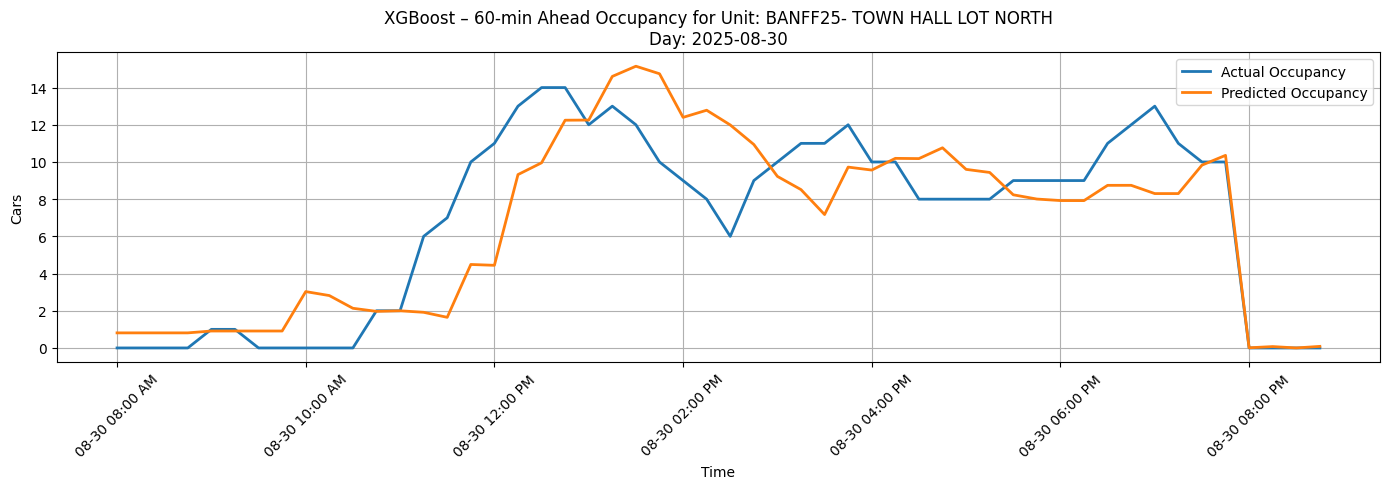

In [16]:
# Plotting the model’s 1-hour-ahead predictions follow the real occupancy during a selected day for a single parking unit.
# Build a test dataframe with timestamps, unit and predictions
y_pred = np.maximum(xgb_pred, 0)
test_df = occ_model.iloc[split_idx:].copy()
test_df['actual'] = y_test.values
test_df['pred']   = y_pred

# Choose a unit
unit_to_plot = test_df['unit'].iloc[0]

# Filter and sort
df_plot = test_df[test_df['unit'] == unit_to_plot].sort_values('ts')

# Create future timestamp (actual occupancy time)
df_plot['future_ts'] = df_plot['ts'] + pd.Timedelta(minutes=60)

# Keep only valid actual rows
df_plot = df_plot[df_plot['actual'].notna()]

# --------------------------
#  Filter for ONE DAY only
# --------------------------
day_to_plot = "2025-08-30"   # ← change the date here

df_plot = df_plot[df_plot['future_ts'].dt.date == pd.to_datetime(day_to_plot).date()]

# AND filter for 8 AM – 8 PM
df_plot = df_plot[(df_plot['future_ts'].dt.hour >= 8) &
                  (df_plot['future_ts'].dt.hour <= 20)]

# --------------------------

plt.figure(figsize=(14,5))

plt.plot(df_plot['future_ts'], df_plot['actual'], label='Actual Occupancy', linewidth=2)
plt.plot(df_plot['future_ts'], df_plot['pred'],   label='Predicted Occupancy', linewidth=2)

plt.title(f"XGBoost – 60-min Ahead Occupancy for Unit: {unit_to_plot}\nDay: {day_to_plot}")
plt.xlabel("Time")
plt.ylabel("Cars")
plt.legend()
plt.grid(True)

# Format x-axis (AM/PM)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %I:%M %p'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


This graph shows the model’s ability to forecast parking occupancy 60 minutes into the future for a single unit on a specific day. Overall, the predicted values (orange line) closely follow the actual occupancy pattern (blue line), successfully capturing the morning increase, mid-day peak, and evening decline. The timing and shape of the peaks are well aligned, and most predictions differ from the actual count by only 1–2 cars. Small deviations are expected in real-world forecasting, but the overall trend and magnitude match strongly. This indicates that the XGBoost model provides accurate and reliable short-term occupancy predictions.

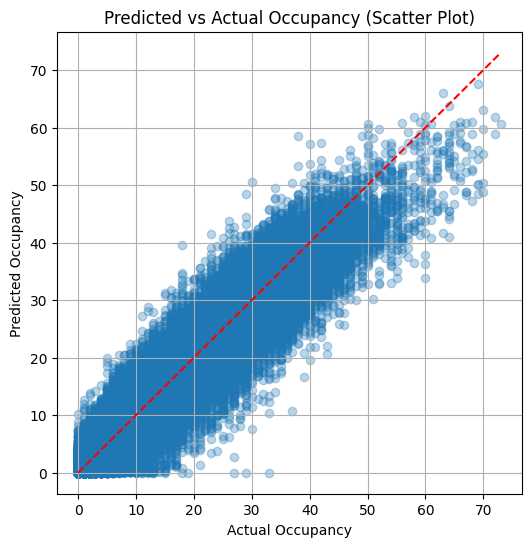

In [18]:
#Plotting scatter plot Predicted vs Actual Occupancy
y_pred = np.maximum(xgb_pred, 0)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.title("Predicted vs Actual Occupancy (Scatter Plot)")
plt.xlabel("Actual Occupancy")
plt.ylabel("Predicted Occupancy")
plt.grid(True)
plt.show()


This scatter plot shows how close the model’s predictions are to the real occupancy values. Each point compares one prediction to what actually happened. Most points fall close to the red diagonal line, which means the model usually predicts the correct number of cars. There is a little more spread when the parking lot is very full, but overall the predictions match the real values very well. This shows that the model is doing a good job.

XGBoost feature importance (sorted):
occupancy       0.445214
lag_1           0.279761
lag_2           0.125591
hour            0.097890
roll_mean_8     0.014326
max_capacity    0.013556
lag_4           0.004956
roll_mean_4     0.004687
is_weekend      0.004484
dayofweek       0.003311
month           0.002597
unit_encoded    0.002251
lag_3           0.001375
dtype: float32


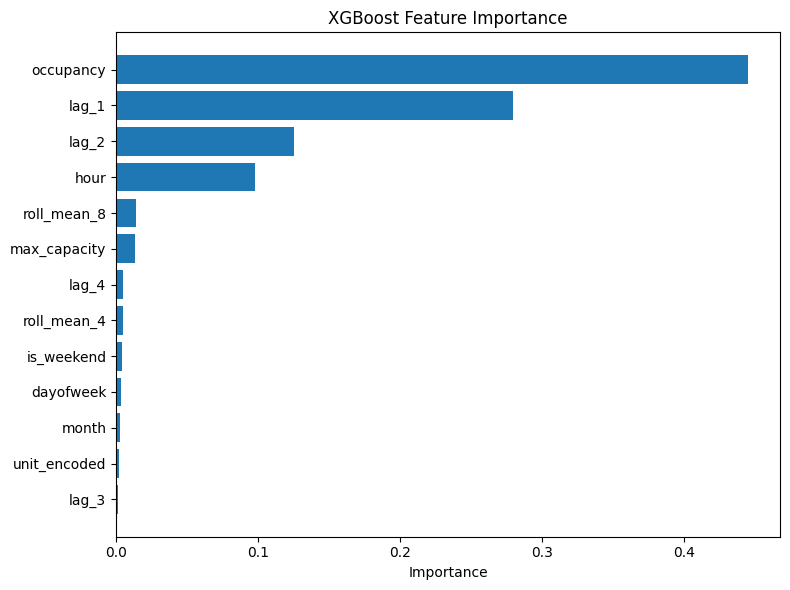

In [19]:
# Plotting feature importance
# Get feature importances from the trained model
importances = xgb_model.feature_importances_   # array of shape (n_features,)

# Map them to your feature names (assuming X_train is a DataFrame)
feat_names = X_train.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

print("XGBoost feature importance (sorted):")
print(feat_imp)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(feat_imp.index, feat_imp.values)
plt.gca().invert_yaxis()  # most important at the top
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


Feature Importance Summary (XGBoost)

The XGBoost feature importance analysis shows that current occupancy is by far the strongest predictor of parking occupancy 60 minutes ahead. This is expected for a short-term forecasting problem, where the most recent state of the parking lot carries the highest predictive power. The next most influential features are lag_1 and lag_2, which capture occupancy 15 and 30 minutes earlier. These lags help the model understand short-term trends such as increasing or decreasing demand.

Time-based features, such as hour of the day, also contribute meaningfully by capturing daily usage patterns, including morning peaks and afternoon activity. Other features—such as rolling averages, max capacity, and categorical variables (weekend, month, unit)—play a smaller role but still help refine the prediction. Overall, the importance ranking confirms that recent occupancy history is the dominant driver of short-term parking demand.

# Block 4: Model Optimization & Hyperparameter Tuning

In [36]:
# --- BASE XGBOOST MODEL (same family as your original one) ---
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42,
)

# --- TIME-SERIES AWARE CV SPLIT ---
# Ensures we only use past data to predict future data in each fold
tscv = TimeSeriesSplit(n_splits=3)

# --- HYPERPARAMETER SEARCH SPACE ---
param_distributions = {
    "n_estimators":    [200, 400, 600],
    "max_depth":       [3, 4, 5, 6],
    "learning_rate":   [0.01, 0.05, 0.1],
    "subsample":       [0.6, 0.8, 1.0],
    "colsample_bytree":[0.6, 0.8, 1.0],
}

# --- RANDOMIZED SEARCH (more efficient than full grid) ---
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=30,                         # number of random combinations to try
    scoring="neg_mean_absolute_error", # we want to minimize MAE
    cv=tscv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Running hyperparameter tuning for XGBoost...")
xgb_search.fit(X_train, y_train)

print("Best hyperparameters found:")
print(xgb_search.best_params_)

# --- TRAIN BEST MODEL ON FULL TRAIN SET ---
best_xgb = xgb_search.best_estimator_

# Evaluate on test set (future data)
y_pred_tuned = best_xgb.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_r2  = r2_score(y_test, y_pred_tuned)

print(f"Tuned XGBoost MAE (cars, 60 min ahead): {tuned_mae:.3f}")
print(f"Tuned XGBoost R² score:                {tuned_r2:.3f}")


Running hyperparameter tuning for XGBoost...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best hyperparameters found:
{'subsample': 0.6, 'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Tuned XGBoost MAE (cars, 60 min ahead): 1.009
Tuned XGBoost R² score:                0.946


Hyperparameter tuning was performed using a 3-fold search over 30 candidate configurations. The best tuned model achieved a test MAE of 1.009 and an R² of 0.946. However, the default XGBoost configuration performed better (MAE = 0.969, R² = 0.950). Therefore, the untuned model was retained as the final model.

In [ ]:
 #SAVE MODEL + ENCODER for streamlit

joblib.dump(model, "parking_xgb_model.pkl")
joblib.dump(le, "unit_label_encoder.pkl")
print("Model and label encoder saved.")

In [ ]:
## Save the DataFrame to a CSV file without the index column
df.to_csv("raw_transactions.csv", index=False)